# Yulu - Hypothesis Testing

## Problem statement and business objective

**Business Problem**  

Yulu has experienced a decline in revenue and wants to understand which factors influence the demand for its shared electric cycles in the Indian market. The goal is to identify the variables that significantly affect demand and determine how well these variables explain variations in demand.


**Business objective**  
*   Identify the factors that influence bike rental demand.
*   Measure the impact of these factors on demand.
*   Provide recommendations to increase rentals and improve revenue.

**Column profiling**

* datetime: datetime
* season: season (1: spring, 2: summer, 3: fall, 4: winter)
* holiday: whether day is a holiday or not (extracted from http://dchr.dc.gov/page/holiday-schedule)
* Workingday: if day is neither weekend nor holiday is 1, otherwise is 0.
* Weather:
  1. Clear, Few clouds, partly cloudy, partly cloudy
  2. Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
  3. Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
  4. Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
* temp: temperature in Celsius
* atemp: feeling temperature in Celsius
* humidity: humidity
* windspeed: wind speed
* casual: count of casual users
* registered: count of registered users
* count: count of total rental bikes including both casual and registered

### EDA (Exploratory data analysis)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Structure checking and characteristics of dataset

In [2]:
df = pd.read_csv("bike_sharing.csv")

df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [3]:
# Checking the shape of data
df.shape

(10886, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


As we can see only datetime column is Object we can change it to date time so that we can access the dates.  
We will also change categorical columns to category which are wrongly mapped to **int64** such as **season, holiday, workingday, weather**

In [5]:
# Conversion of datetime to correct format
df["datetime"] = pd.to_datetime(df["datetime"])
df["year"] = df["datetime"].dt.year
df["month_name"] = df["datetime"].dt.month_name()
month_order = ["January", "February", "March", "April", "May", "June", 
               "July", "August", "September", "October", "November", "December"]
df["month_name"] = pd.Categorical(df["month_name"], categories=month_order, ordered=True)

In [6]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month_name
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,January
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,January
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,January
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,January
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,January


In [7]:
# Converting season, holiday, workingday, weather to category datatype
df[["season", "holiday", "workingday", "weather"]] = df[["season", "holiday", "workingday", "weather"]].astype("category")

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[us]
 1   season      10886 non-null  category      
 2   holiday     10886 non-null  category      
 3   workingday  10886 non-null  category      
 4   weather     10886 non-null  category      
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month_name  10886 non-null  category      
dtypes: category(5), datetime64[us](1), float64(3), int32(1), int64(4)
memory usage: 776.7 KB


As we can say columns data types have been changed to there correct types this will help us with our further analysis.  
Moving forward lets change **season**, **holiday** and **workingday** from numbers to there proper names as already stated in the column profiling.

In [9]:
# Converted season, holiday and workingday categories to its proper names.
category_maps = {
    "season": {
        1: "spring",
        2: "summer",
        3: "fall",
        4: "winter"
    },
    "holiday": {
        0: "No",
        1: "Yes"
    },
    "workingday": {
        0: "No",
        1: "Yes"
    },
    "weather": {
        1: "clear",
        2: "misty",
        3: "light snow/rain",
        4: "heavy snow/rain"
    }
}

for col, mapping in category_maps.items():
    df[col] = df[col].cat.rename_categories(mapping)

In [10]:
df.tail()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month_name
10881,2012-12-19 19:00:00,winter,No,Yes,clear,15.58,19.695,50,26.0027,7,329,336,2012,December
10882,2012-12-19 20:00:00,winter,No,Yes,clear,14.76,17.425,57,15.0013,10,231,241,2012,December
10883,2012-12-19 21:00:00,winter,No,Yes,clear,13.94,15.910,61,15.0013,4,164,168,2012,December
10884,2012-12-19 22:00:00,winter,No,Yes,clear,13.94,17.425,61,6.0032,12,117,129,2012,December
10885,2012-12-19 23:00:00,winter,No,Yes,clear,13.12,16.665,66,8.9981,4,84,88,2012,December


Checking null values

In [11]:
df.isna().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
year          0
month_name    0
dtype: int64

As we can see there are no null values. Hence no data cleaning is required.

#### Univariate analysis

##### Numerical data
Now I will do Univarate analysis on the target variable that is count to check the distribution of the data. This distribution information will be crucial to apply the necessary statistical test.

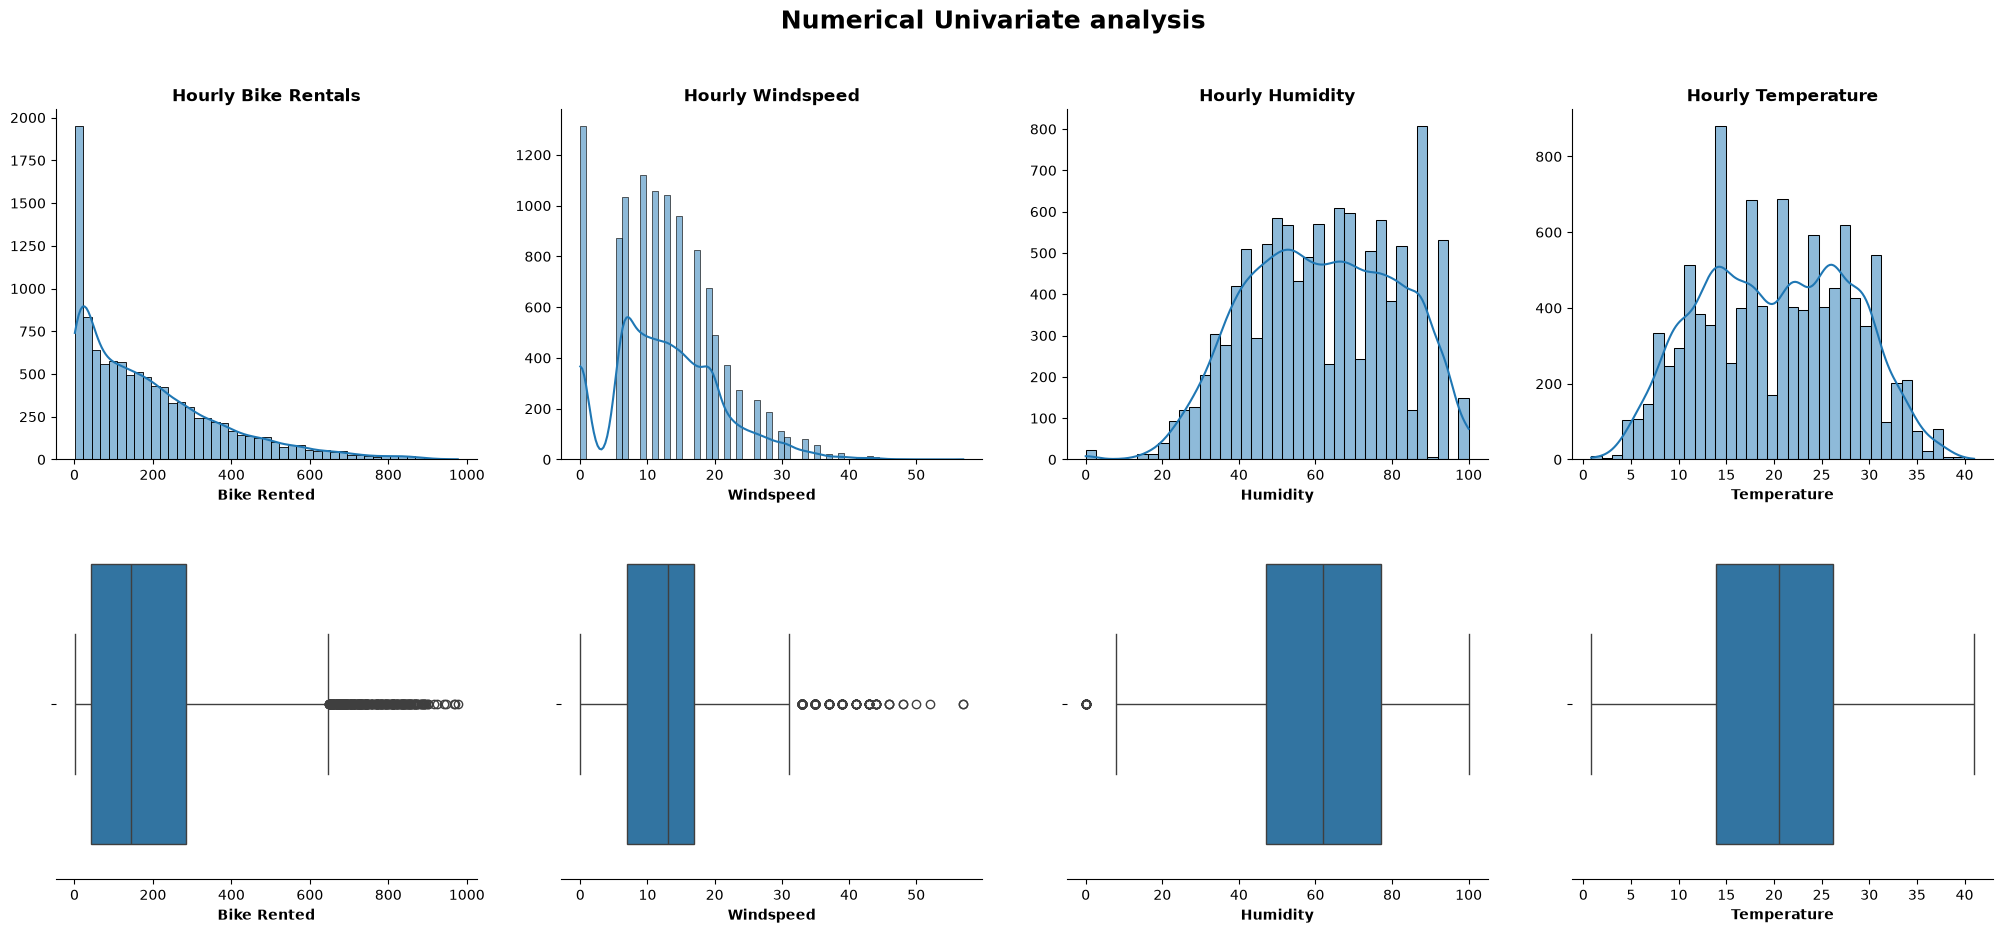

In [12]:
fig, axes = plt.subplots(2,4, figsize=(25,10))
fig.suptitle("Numerical Univariate analysis", fontsize=18, weight="bold")

columns = ["count", "windspeed", "humidity", "temp"]
titles = ["Hourly Bike Rentals", "Hourly Windspeed", "Hourly Humidity", "Hourly Temperature"]

for i, (col, title) in enumerate(zip(columns, titles)):
    sns.histplot(
    data=df, 
    x=col, 
    kde=True, 
    ax=axes[0,i]
    )

    axes[0, i].spines[["top", "right"]].set_visible(False)
    axes[0, i].set_title(title, weight="bold")
    axes[0, i].set(ylabel=None)

    if col == "count" or col == "windspeed" or col == "humidity" or col == "temp":
        axes[0, 0].set_xlabel("Bike Rented", weight="bold")
        axes[0, 1].set_xlabel("Windspeed", weight="bold")
        axes[0, 2].set_xlabel("Humidity", weight="bold")
        axes[0, 3].set_xlabel("Temperature", weight="bold")

    sns.boxplot(
        data=df, 
        x=col, 
        ax=axes[1,i]
    )

    axes[1, i].spines[["top", "right", "left"]].set_visible(False)

    if col == "count" or col == "windspeed" or col == "humidity" or col == "temp":
        axes[1,0].set_xlabel("Bike Rented", weight="bold")
        axes[1,1].set_xlabel("Windspeed", weight="bold")
        axes[1,2].set_xlabel("Humidity", weight="bold")
        axes[1,3].set_xlabel("Temperature", weight="bold")
        

plt.show()

In [13]:
num_cols = ["count", "windspeed", "humidity", "temp"]

summary = df[num_cols].describe()

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ((df[num_cols] < lower_bound) |
            (df[num_cols] > upper_bound)).sum()

summary.loc["IQR"] = IQR
summary.loc["Lower Bound"] = lower_bound
summary.loc["Upper Bound"] = upper_bound
summary.loc["Outliers"] = outliers

summary

,count,windspeed,humidity,temp
count,10886.000000,10886.000000,10886.000000,10886.00000
mean,191.574132,12.799395,61.886460,20.23086
std,181.144454,8.164537,19.245033,7.79159
min,1.000000,0.000000,0.000000,0.82000
25%,42.000000,7.001500,47.000000,13.94000
50%,145.000000,12.998000,62.000000,20.50000
75%,284.000000,16.997900,77.000000,26.24000
max,977.000000,56.996900,100.000000,41.00000
IQR,242.000000,9.996400,30.000000,12.30000
Lower Bound,-321.000000,-7.993100,2.000000,-4.51000


**Count**
* The count variable is positively (right) skewed, with the central 50% of observations lying between 42 and 284 rentals, based on Q1 and Q3.
* Most hourly observations have relatively low rental counts, while only a smaller number of hours experience very high rental demand, resulting in a long right tail.
* The IQR method identifies 300 observations above the upper bound of 647 rentals, indicating that these hours experienced unusually high rental counts relative to the central distribution.

**Windspeed**
* The windspeed variable is positively (right) skewed, with the central 50% of observations lying between 7 and 17, and a median of 13.
* Most hourly observations have relatively low windspeed values, while only a smaller number of hours experience very high windspeeds, reaching up to 57.
* The IQR method identifies 227 observations above the upper bound of approximately 32, indicating unusually high windspeed values compared with the central distribution.

**Humidity**
* The humidity variable is negatively (left) skewed, with the central 50% of observations lying between 47 and 77, and a median of 62.
* Most hourly observations occur at relatively higher humidity levels, while fewer observations occur at lower humidity levels.
* The IQR method identifies observations below the lower bound of approximately 22 as potential outliers, indicating unusually low humidity values.

**Temp**
* The temp distribution appears multimodal, with multiple peaks rather than a single dominant peak. The mean and median are relatively close, and the central 50% of observations lie approximately between 14 and 26.
* The majority of observations are concentrated around moderate temperature values, while both very low and very high temperatures occur less frequently.

##### Categorical data

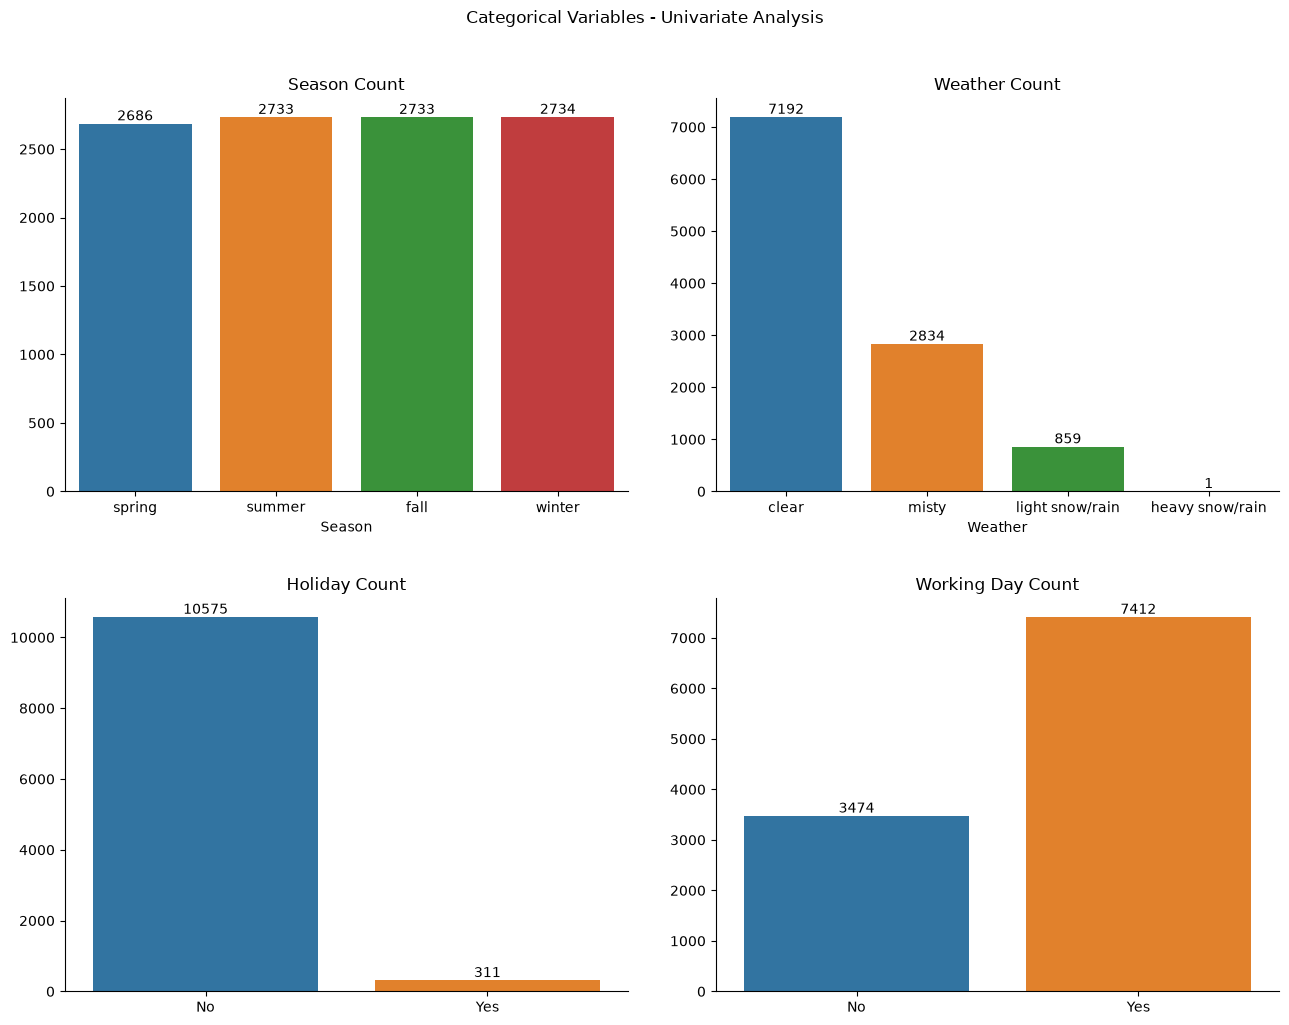

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Categorical Variables - Univariate Analysis", y=1.02)

plot_config = [
    ("season", "Season Count", "Season"),
    ("weather", "Weather Count", "Weather"),
    ("holiday", "Holiday Count", None),
    ("workingday", "Working Day Count", None)
]

for ax, (column, title, xlabel) in zip(axes.flat, plot_config):

    sns.countplot(
        data=df,
        x=column,
        hue=column,
        dodge=False,
        legend=False,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(None)

    ax.spines[["top", "right"]].set_visible(False)

    for container in ax.containers:
        ax.bar_label(container)

plt.tight_layout(h_pad=3.0, w_pad=3.0)
plt.show()

**Season**
* The number of observations is relatively evenly distributed across seasons, with Spring having the lowest number of observations (2,686) and Winter having the highest (2,734).

**Weather**
* Weather category 1 (Clear/Partly Cloudy) has the highest number of observations (7,192), while Weather category 4 has only one observation, making it an extremely rare category in the dataset.

**Holiday**
* Non-holiday days account for the vast majority of observations (10,575), while only 311 observations correspond to holidays.

**Workinday**
* Working days account for a substantially larger number of observations (7,412) compared with non-working days (3,474).

#### Bivariate analysis



Lets explore relationship between 2 variables now.  

##### Numerical vs Categorical

* Season vs Count
* Weather vs Count
* Workingday vs Count

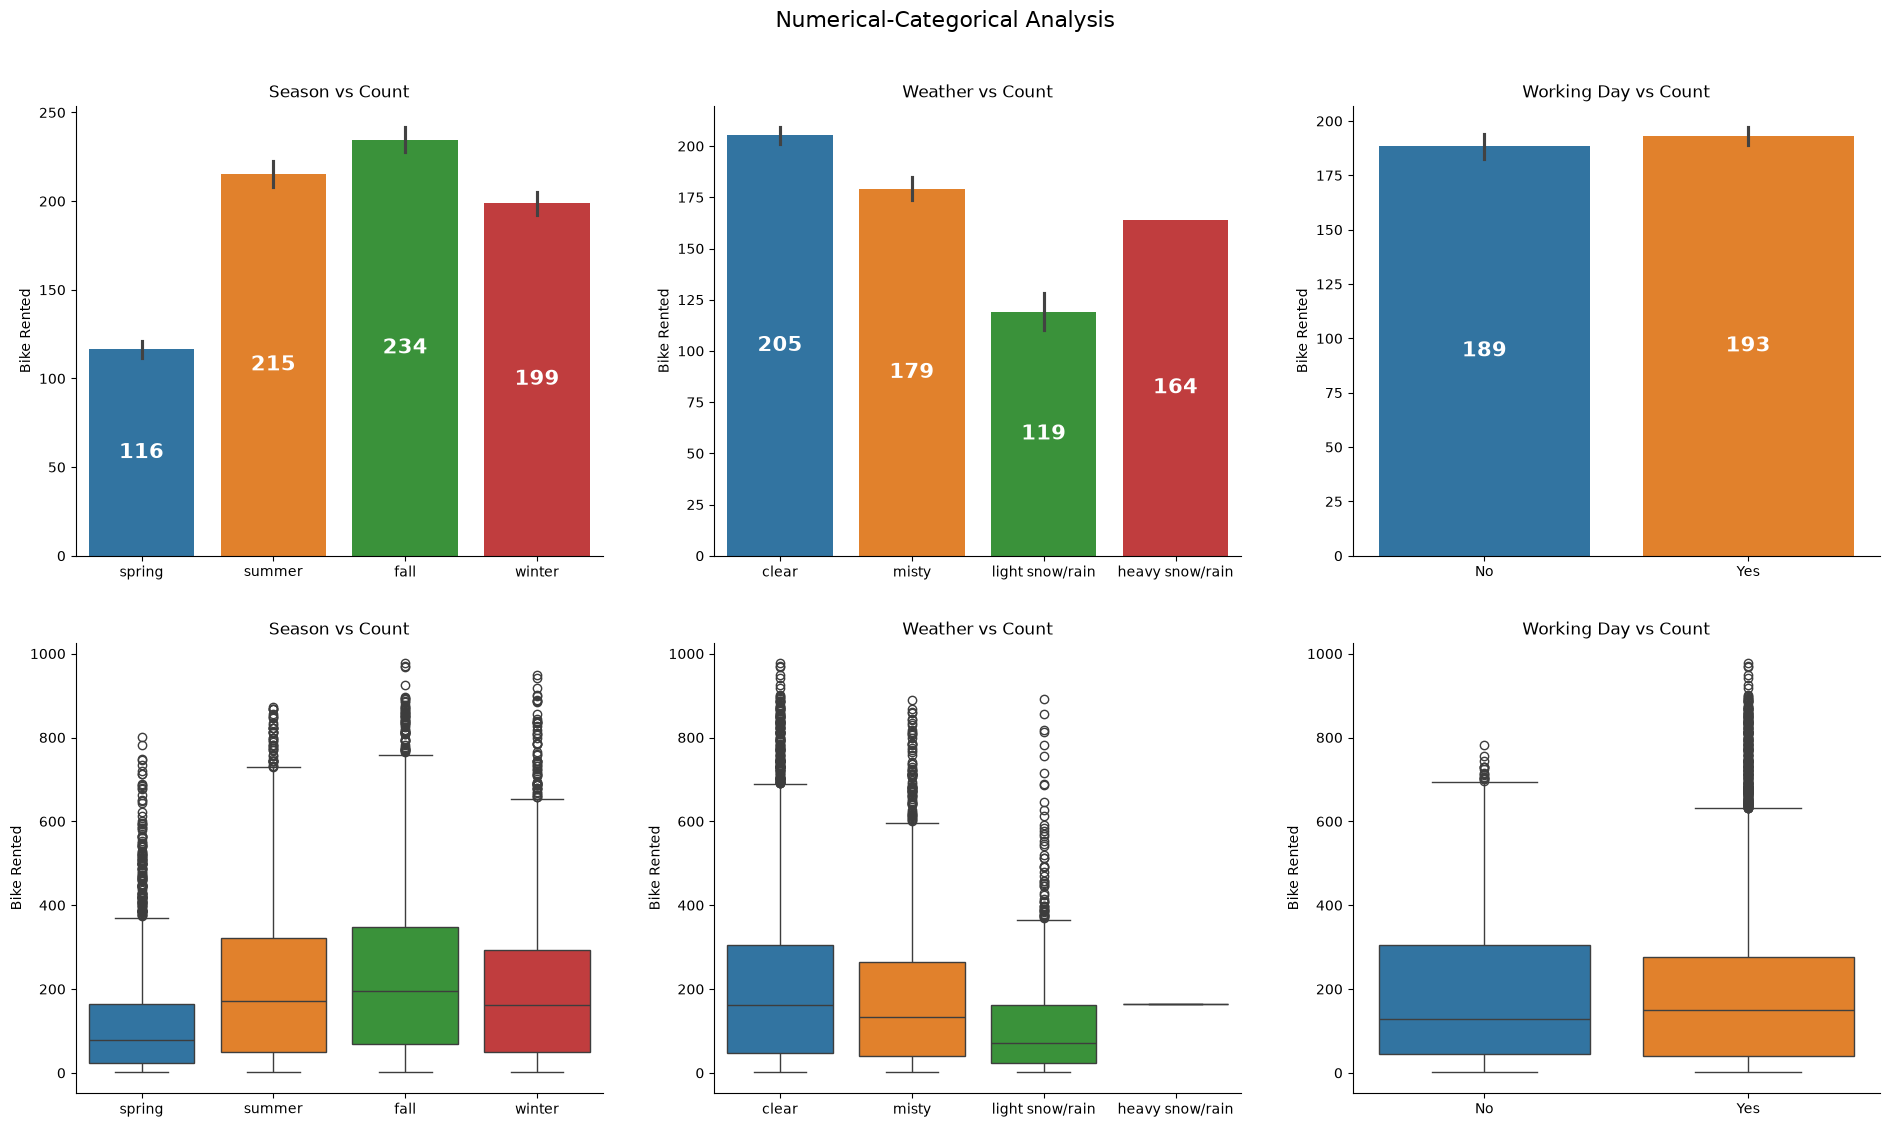

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(19, 11))
fig.suptitle("Numerical-Categorical Analysis", fontsize=16, y=1.02)

columns = ["season", "weather", "workingday"]
titles = ["Season vs Count", "Weather vs Count", "Working Day vs Count"]

for i, (col, title) in enumerate(zip(columns, titles)):

    # Barplots - first row
    sns.barplot(
        data=df,
        x=col,
        y="count",
        hue=col,
        dodge=False,
        legend=False,
        ax=axes[0, i]
    )

    axes[0, i].set_title(title)

    for container in axes[0, i].containers:
        axes[0, i].bar_label(container, fmt="%.0f", label_type="center", fontsize=15, weight="bold", color="white")

    # Boxplots - second row
    sns.boxplot(
        data=df,
        x=col,
        y="count",
        hue=col,
        dodge=False,
        legend=False,
        ax=axes[1, i]
    )

    
    axes[1, i].set_title(title)

    # Common formatting for both plots
    axes[0, i].spines[["top", "right"]].set_visible(False)
    axes[0, i].set(ylabel="Bike Rented", xlabel=None)
    axes[1, i].spines[["top", "right"]].set_visible(False)
    axes[1, i].set(ylabel="Bike Rented", xlabel=None)

plt.tight_layout(h_pad=3.0, w_pad=3.0)
plt.show()

Here are few observations:  
**Seasons**
* Fall has the highest average hourly rental count (234), while Spring has the lowest (116), suggesting that average rental demand varies considerably across seasons.
* Spring has the lowest median rental count among the seasons, while several high-demand observations appear as potential outliers.
* Fall has the highest median rental count and the widest IQR among the four seasons, indicating greater variability in hourly rental demand.

**Weather**
* Weather category 1 has the highest average rental count (205), while weather category 3 has the lowest (119). This suggests that rental demand may vary across weather conditions.
* Weather category 3 has the lowest median rental count and shows a substantial number of high-demand observations beyond the upper whisker, indicating considerable variability within this category.
* Weather category 4 has a higher average rental count (164) than category 3 (119), despite having substantially fewer observations. The boxplot for category 4 is compressed/collapsed because of its very small sample size, so the observed mean should be interpreted cautiously.

**Working day**
* The average hourly rental count is slightly higher on working days (193) compared with non-working days (189).
* The non-working day category has a wider IQR than the working-day category, indicating greater variability in the middle 50% of rental counts.
* The median rental counts for working and non-working days are relatively similar, indicating that the typical rental demand is comparable between the two categories.
* The two boxplots show substantial overlap, suggesting that the difference in rental demand between working and non-working days may be relatively small compared with the overall variability.

##### Categorical vs Categorical

* Season vs Weather
* Weather vs Working Day

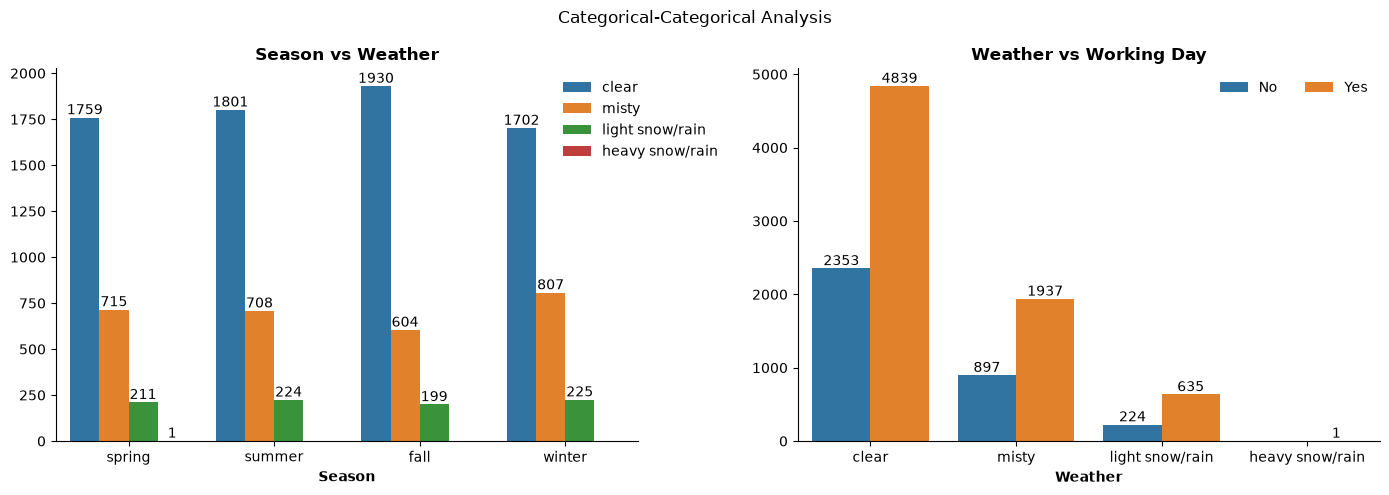

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Categorical-Categorical Analysis")

plot_config = [
    ("season", "weather", "Season vs Weather"),
    ("weather", "workingday", "Weather vs Working Day")
]

for ax, (x_col, hue_col, title) in zip(axes, plot_config):

    sns.countplot(
        data=df,
        x=x_col,
        hue=hue_col,
        ax=ax
    )

    ax.set_title(title, weight="bold")
    ax.set_xlabel(x_col.capitalize(), weight="bold")
    ax.set_ylabel(None)
    ax.spines[["top", "right"]].set_visible(False)

    if x_col == "season":
        ax.legend(bbox_to_anchor=(0.85,1.0), frameon=False)
    if x_col == "weather":
        ax.legend(frameon=False, ncol=2)

    for container in ax.containers:
        ax.bar_label(container)

plt.tight_layout()
plt.show()

Season vs Weather
* Weather category 1 (Clear/Partly Cloudy) has the highest number of observations in every season, with the highest frequency occurring in Fall (1,930 observations).
* Weather category 2 is the second most frequently observed weather condition across all seasons, with the highest number of observations occurring in Winter (807).
* Category 3 Light rainy weather has almost same number of observations in all season but one observation higher in winter as compared to summer.
* Weather category 4 is extremely rare, with only one observation in the entire dataset, occurring during Spring.

Weather vs Workingday
* Working-day observations are higher across all weather categories, with Weather category 1 (Clear/Partly Cloudy) having the highest frequency.
* Non-working days also have observations across Weather categories 1, 2 and 3, but their frequencies are considerably lower than those of working days.
* Weather category 4 is extremely rare, with only one observation in the entire dataset, and it occurred on a working day.

##### Numerical vs Numerical

* Temp vs Count
* Humidity vs Count
* Windspeed vs Count

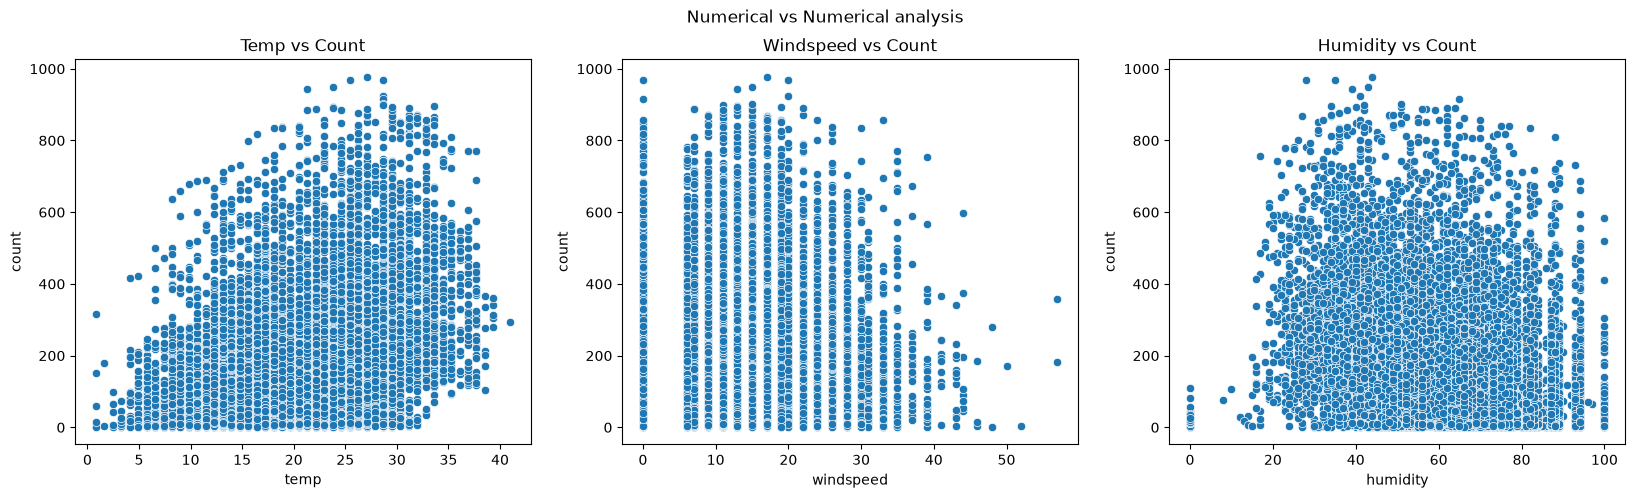

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(20,5))
fig.suptitle("Numerical vs Numerical analysis")

plt.subplot(1,3,1)
plt.title("Temp vs Count")
sns.scatterplot(data=df, x="temp", y="count")

plt.subplot(1,3,2)
plt.title("Windspeed vs Count")
sns.scatterplot(data=df, x="windspeed", y="count")

plt.subplot(1,3,3)
plt.title("Humidity vs Count")
sns.scatterplot(data=df, x="humidity", y="count")

plt.show()


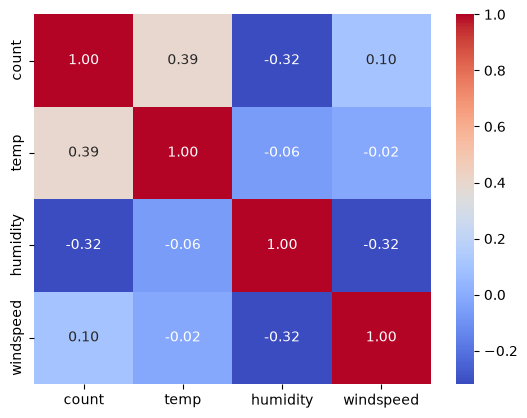

In [18]:
sns.heatmap(df[["count", "temp", "humidity", "windspeed"]].corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.show()

Temp vs Count
* temp and count show a moderate positive correlation (r ≈ 0.39), suggesting that bike rentals generally tend to increase as temperature increases. However, the scatterplot shows considerable dispersion, indicating that temperature alone does not explain rental demand.
* Rental counts tend to increase as temperature rises from lower levels and reach higher values around 20-30°C. Beyond this range, rental counts generally tend to decline, suggesting that extremely high temperatures may be associated with lower rental demand.

Windspeed vs Count
* windspeed and count have a very weak positive linear correlation (r = 0.10). However, the scatterplot does not show a clear strong linear pattern, indicating that windspeed has a weak linear association with rental count.
* Higher rental counts are more concentrated at lower to moderate windspeeds, while rental counts generally become lower as windspeed increases beyond approximately 20-25.

Humidity vs Count
* Higher rental counts are more frequently observed at moderate humidity levels, while very high humidity levels generally show fewer high rental counts.
* Humidity and count have a moderate negative Pearson correlation (r = -0.32). However, the scatterplot does not show a clear linear pattern, suggesting that the relationship may not be purely linear.

### Additonal EDA

#### Multivariate analysis

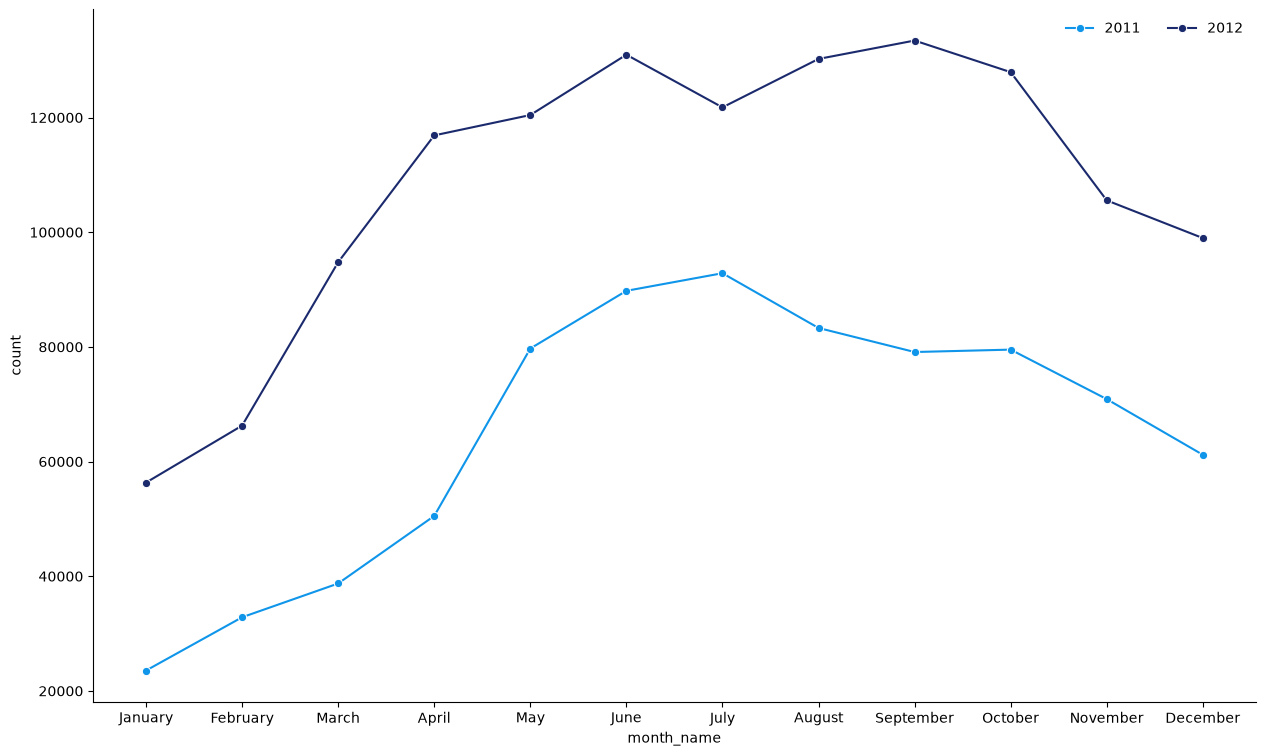

In [94]:
fig, ax = plt.subplots(figsize=(15,9))

year_palette = ["#0F95E9", "#1B2A6D"]

sns.lineplot(df.groupby(["year", "month_name"])["count"].sum().reset_index(), 
             x="month_name", y="count", hue="year", marker="o", palette=year_palette)

ax.spines[["top", "right"]].set_visible(False)
ax.legend(ncol=2, frameon=False)

plt.show()

##### Numerical vs Numerical vs Numerical

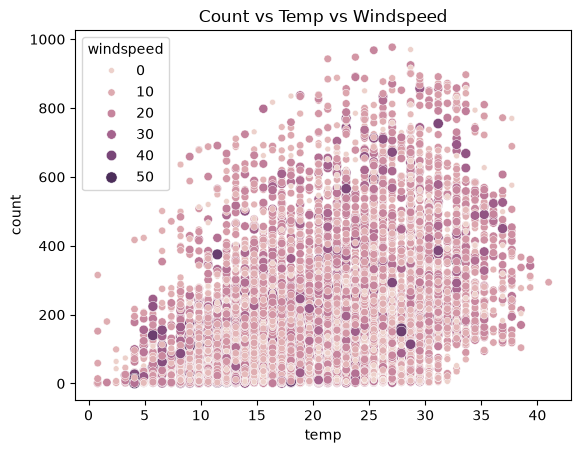

In [19]:
plt.title("Count vs Temp vs Windspeed")
sns.scatterplot(data=df, x="temp", y="count", size="windspeed", hue="windspeed")
plt.show()

* Higher rental counts are predominantly observed between 20-30°C, particularly at low-to-moderate windspeeds (approximately 0-20).
* At lower temperatures, observations with higher windspeeds generally correspond to lower rental counts.
* Most observations are concentrated at windspeeds between approximately 0-30, with relatively fewer observations at higher windspeeds.
* Extremely high rental counts are concentrated around moderate temperatures, while very low and very high temperatures show fewer observations with exceptionally high demand.
* Although high rental counts are more frequently observed at lower-to-moderate windspeeds, some relatively high rental counts also occur at higher windspeeds, suggesting that windspeed alone does not determine rental demand.

##### Numerical vs Numerical vs Categorical

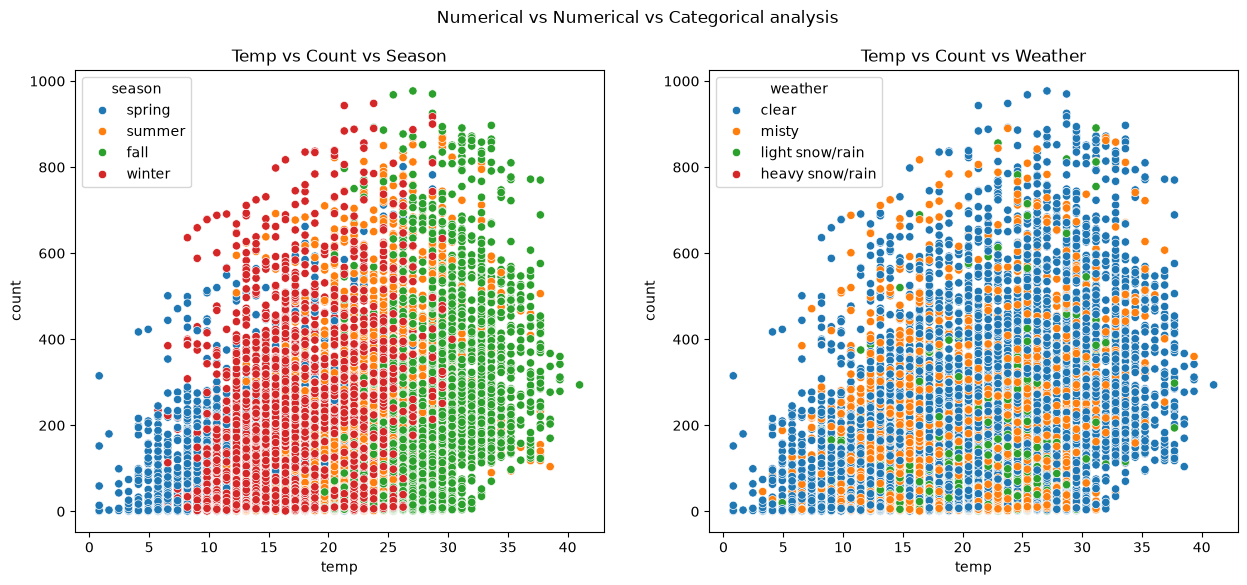

In [46]:
plt.figure(figsize=(15,6)).suptitle("Numerical vs Numerical vs Categorical analysis")

plt.subplot(1,2,1)
plt.title("Temp vs Count vs Season")
sns.scatterplot(data=df, x="temp", y="count", hue="season")

plt.subplot(1,2,2)
plt.title("Temp vs Count vs Weather")
sns.scatterplot(data=df, x="temp", y="count", hue="weather")

plt.show()

Temp vs Count vs Season
* Spring temperatures are mostly distributed between approximately 0-30°C, with rental counts generally increasing as temperature increases.
* Winter temperatures are mostly distributed between approximately 5-30°C, with rental counts generally increasing with temperature. However, its average rental demand is lower than fall and summer.
* Summer temperatures are distributed approximately between 10–40°C. Rental counts generally increase with temperature, with summer having the second-highest average rental demand after fall.
* Fall shows the highest average rental demand among all seasons, with many high-count observations concentrated around approximately 25–35°C. Its temperature range appears narrower than summer's.
* The relationship between temperature and rental demand varies across seasons. Fall contains a greater concentration of high-demand observations, while spring generally shows lower rental demand at comparable temperatures. This suggests that season may provide additional context to the relationship between temperature and rental demand.

Temp vs Count vs Weather
* Weather category 1 (Clear/Partly Cloudy) contains the majority of observations and covers the widest temperature range, approximately 0–40°C. It also contains many of the higher rental-count observations.
* Weather category 2 (Mist/Cloudy) has fewer observations than category 1 but still contains a substantial number of higher rental-count observations across a relatively wide temperature range.
* Weather category 3 (Light Rain/Light Snow) has considerably fewer observations and generally lower rental counts compared with weather categories 1 and 2.
* For weather categories 1 and 2, higher rental counts are concentrated around moderate-to-high temperatures, whereas category 3 generally shows lower rental counts even across overlapping temperature ranges.

##### Categorical vs Categorical vs Numerical

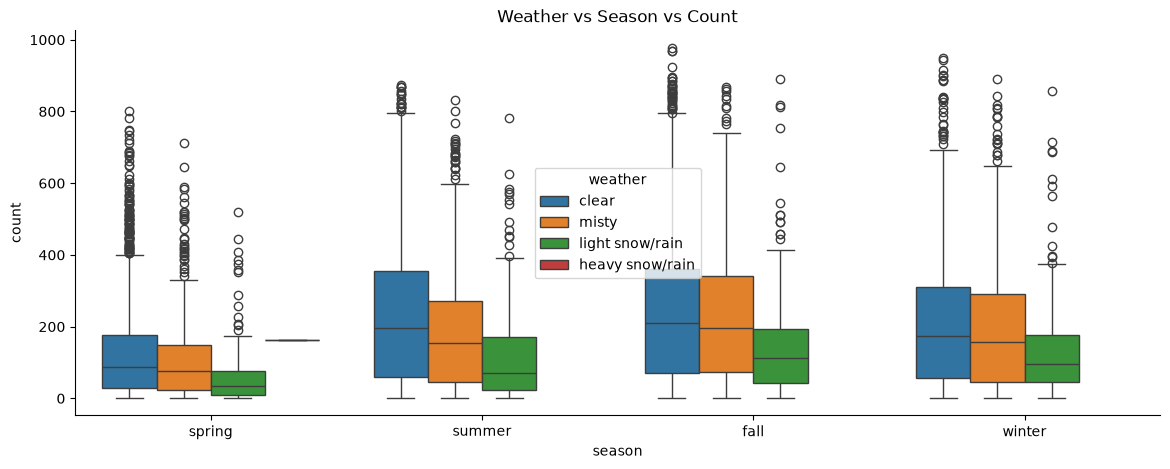

In [21]:
fig, ax = plt.subplots(figsize=(14,5))

sns.boxplot(data=df, x="season", y="count", hue="weather")
ax.set_title("Weather vs Season vs Count")
ax.spines[["top", "right"]].set_visible(False)

plt.show()
